# **ESERCIZIO 2.1**


**OBIETTIVI**

L'obiettivo dell'esercizio 2.1 è calcolare l'integrale 1D
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$
tramite il metodo Monte Carlo in due modi differenti:

- campionando una distribuzione uniforme in $[0,1]$
- usando importance sampling (cioè scegliendo di campionare una distribuzione non uniforme in $[0,1]$)

**IMPLEMENTAZIONE**

Per eseguire l'esercizio, ho impostato una simulazione con 10 000 estrazioni totali divise in 100 blocchi, ciascuno da 100 lanci.

In particolare, l'importance sampling richiede di campionare secondo una distribuzione di probabilità che approssimi l'andamento della funzione integranda nell'intervallo di integrazione. Infatti, il metodo dell'importance sampling consiste nel riscrivere l'integrale come $\int_a^b \frac{f(x)}{d(x)}d(x)dx$. In questo modo, devo quindi mediare i valori del rapporto $f(x)/d(x)$, campionando le x secondo la distribuzione $d(x)$. Io ho scelto come $d(x)$ la retta $y=2(1-x)$, trovata nel modo seguente:

- $y=ax+b$
- in $(1,0)$ voglio y=0 $\rightarrow $ $y=ax-a$
- essendo una densità di probablità, impongo la normalizzazione dell'integrale, ossia $1=\int^1_0 ydx=\int^1_0 axdx-\int^1_0 adx=-0.5 a \rightarrow a=-2$
- $y=-2x+2$

Per generare i numeri casuali distribuiti secondo $p(x)=y=2(1-x)$, ho usato il metodo dell'inversione della cumulativa:

- definisco la funzione cumulativa $F(x)=\int_0^x p(t)dt=\int_0^x 2(1-t)dt=2x-x^2$
- pongo $u=F(x)=2x-x^2$, dove $u$ è la variabile casuale estratta uniformemnte in $[0,1]$
- dal momento che il generatore è in grado di estrarre un numero $u$ estratto uniformemente in $[0,1]$, inverto la formula in modo che abbia come parametro $u$: $x=1-\sqrt{1-u}$



Dovendo calcolare media ed errore con il metodo a blocchi, ho impostato il ciclo esterno sul numero di blocchi, e quello interno sui lanci per ciascun blocco. In particolare, nel ciclo interno genero ad ogni lancio un numero casuale estratto tra 0 e 1. Dopodichè, per l'importance sampling uso il valore estratto per calcolare $x=(1-\sqrt{1-u})$. Infine, notando che $b-a=1-0=1$, calcolo e accumulo i due integrali:

- $I_1=\frac{\pi\cos(\pi \frac{u}{2})}{2}$ per ditribuzione uniforme 
- $I_2=\frac{\pi\cos(\pi \frac{x}{2})}{4(1-x)}$ per IS


Per ogni blocco calcolo e stampo media ed errore progressivo.

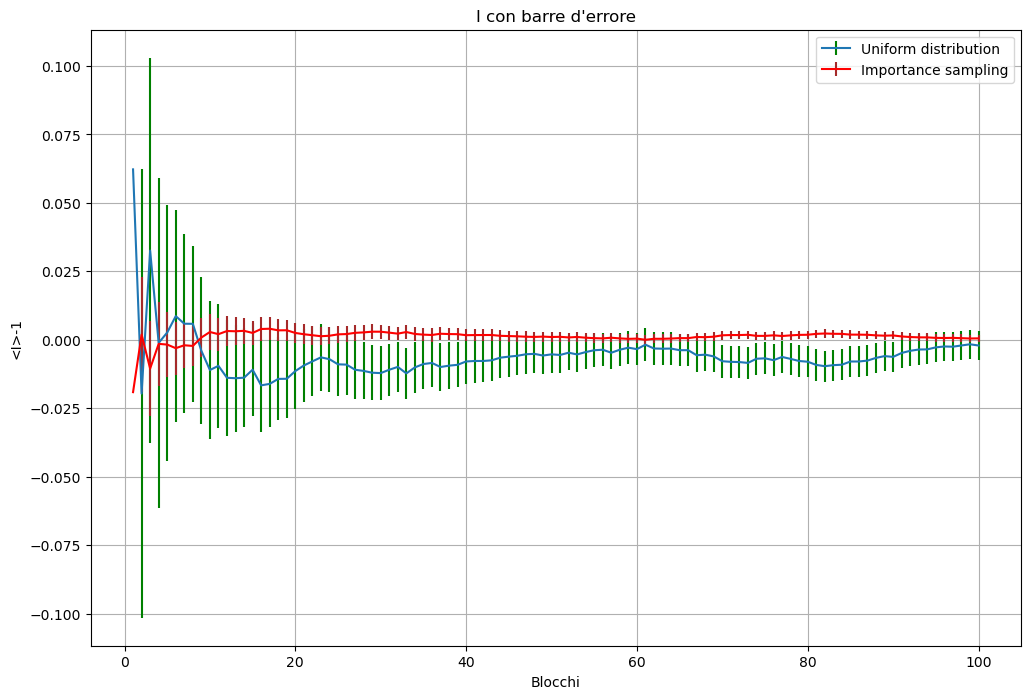

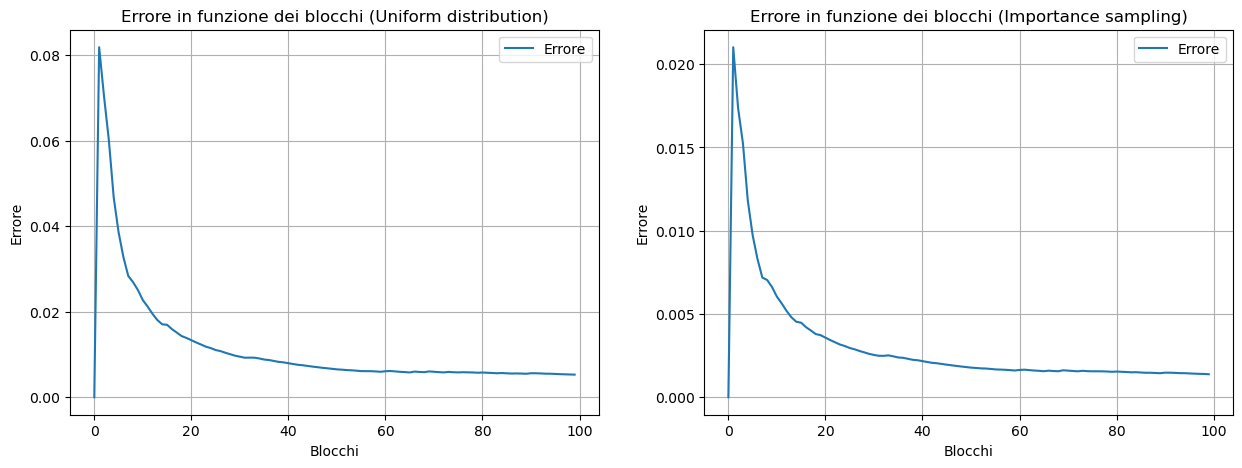

In [1]:
import numpy as np
import matplotlib.pyplot as plt

M=10000 #Llanci
N=100 #blochi
L=int(M/N)  #lanci per blocco

#carico i dati
dati=np.loadtxt("02.1/Metodo1.dat")
datiJ=np.loadtxt("02.1/Metodo2.dat")

#indice blocco
x=dati[:,0]

#seleziono le colonne di media ed errore progressivo
media=dati[:,1]
errore=dati[:,2]

mediaJ=datiJ[:,1]
erroreJ=datiJ[:,2]

plt.figure(figsize=(12,8))


plt.errorbar(x, media-1, yerr=errore, ecolor='green', label="Uniform distribution")
plt.errorbar(x, mediaJ-1, yerr=erroreJ, color="red", ecolor='brown', label="Importance sampling")

plt.xlabel('Blocchi')
plt.ylabel('<I>-1')
plt.title("I con barre d'errore")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(errore,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Uniform distribution)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(erroreJ,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Importance sampling)")
plt.legend()
plt.grid(True)
plt.show()

**COMMENTO AI RISULTATI**

Entrambi i grafici (UD e IS) mostrano chiaramente la convergenza delle stime al valore esatto dell'integrale (1). I grafici però mostrano un'evidente differenza tra i diversi metodi per quanto riguarda le barre d'errore e le fluttuazioni dei valori: il metodo UD è caratterizzato da errori e fluttuazioni più marcate; il metodo di IS ha invece errori più piccoli e fluttuazioni più ridotte, e dimostra quidni di essere il metodo più efficiente.

Questo è dovuto al fatto che il campionamento uniforme si calcola la media di $f(x)$, che può assumere valori anche molto diversi tra loro nel dominio in cui è definito l'integrale, e quindi i valori campionati oscillano molto. Al contrario, con il metodo di importance sampling si calcola la media di $f/d$ e, poichè $d$ è stata scelta in modo che ricalcasse l'andamento di $f$, questo rapporto risulta essere quasi costante e pertanto i valori campionati non oscillano ma sono simili tra loro.

# **ESERCIZIO 2.2**


**OBIETTIVI**

L'obiettivo dell'esercizio è ripetere 10 000 volte la simulazione di una random walk tridimensionale partendo dall'origine. In particolare, devo fare due diverse simulazioni:

- su un reticolo cubico di lato $a=1$, in cui a ogni tempo chi cammina compie un passo avanti o indietro di una unità, in una delle tre direzioni x,y,z. Sia la direzione sia il segno dello spostmento sono estratti casualmente.
- nel continuo, ovvero chi cammina può compiere un passo in qualsiasi direzione, campionando uniformemente l'angolo solido, ma sempre di ampiezza $a=1$

Per entrambi i random walk, devo poi fare un grafico in cui rappresento $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ con il suo errore statistico, in funzione del numero di passi $i\in [0,10^2]$. Infine, fitto i grafici con una funzione  $f(N)=k\sqrt{N}$.

**IMPLEMENTAZIONE**

Per la simulazione ho usato un numero di blocchi pari a 100, e un numero di lanci per blocco pari a 100, per un totale di 10 000 passi. Inoltre, ho simulato ciascuna random walk usando 100 passi.
Per entrambe le simulazioni, devo fare un ciclo esterno sui blocchi, all'inizio del quale azzero il vettore $distanza2$, che accumula in ogni indice (che corrisponde al numero dello step eseguito) il valore di $r^2$, con $r$ distanza dall'origine. Dopodichè, eseguo un primo ciclo interno sul numero di RW (100) che devo eseguire, al fine di azzerare i tre vettori $pos$, che accumulano la distanza percorsa in ciascuna delle tre direzioni: in queesto modo, sono sicura che ciascuna RW partirà dall'origine. 

1. RETICOLO CUBICO: all'interno di questo ciclo eseguo un altro ciclo, eseguito sul numero di steps (100), in cui genero uniformemente $u\in [0,5]$: in questo modo, la parte intera di questo valore può assumere 6 valori, ognuno corrispondente a una condizione di movimento (ad esempio, 0=mi muovo di -1 in direzione x).
   
    Calcolo $r^2$ e lo inserisco in $distanza2$. Infine, uso il metodo a blocchi per stimare valor medio e incertezza. In particolare, l’errore sul valor medio è stato stimato tramite il metodo a blocchi, assumendo i blocchi indipendenti: l’incertezza è stata calcolata come deviazione standard della media tra blocchi, secondo la formula classica della varianza campionaria: $\sigma_{\langle x \rangle}= \sqrt{\frac{\langle x^2 \rangle - \langle x \rangle ^2}{N-1}}$, con N numero di blocchi.
   
3. ANGOLO SOLIDO: devo campionare uniformemente l'angolo solido, ovvero tutti i punti della superficie sferica devono avere la stessa probabilità di essere estratti. Quindi, devo campionare i punti secondo una distribuzione che segua la superficie della sfera. Visto che l'elemento infinitesimo di area sulla sfera è $d\Omega=\sin\theta d\theta d\phi=d(\cos\theta) d\phi$, la distribuzione risulta essere uniforme in $\phi$ e in $\cos\theta$, che sono gli elementi infinitesimi che descrivono la sfera. Inoltre, il fattore $\sin\theta$ fa sì che le regioni vicino all'equatore abbiano area maggiore di quelle vicino ai poli. Infatti, l'equatore si ha per $\theta=\frac{\pi}{2} \rightarrow \sin\theta=1$; al contrario, i poli si hanno per $\theta=0 \text{ V } \theta=\pi \rightarrow \sin\theta=0$.

    Per questo motivo, per campionare uniformemente l'angolo solido, devo:

    - estrarre uniformemente un valore $u\in [-1,1]$, che rappresenta il $\cos\theta$
    - ricavo l'espressione per $\sin\theta$: $\sin\theta=\sqrt{1-u^2}$

   Infine, anche in questo caso uso il metodo a blocchi per calcolare media ed errore.

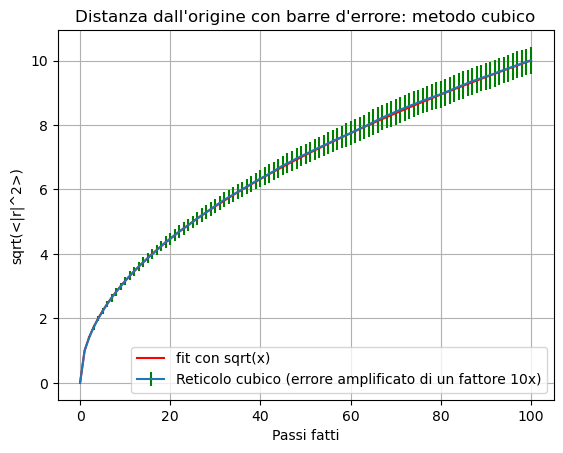

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#carico i dati
RW1=np.loadtxt("02.2/Metodo1.dat")

x=RW1[:,0]  #passi
media=RW1[:,1]  
errore=RW1[:,2]  


plt.figure()


plt.errorbar(x, media, yerr=errore*10, ecolor='green', label="Reticolo cubico (errore amplificato di un fattore 10x)")
plt.plot(x,np.sqrt(x), color="red", label="fit con sqrt(x)")

plt.xlabel('Passi fatti')
plt.ylabel('sqrt(<|r|^2>)')
plt.title("Distanza dall'origine con barre d'errore: metodo cubico")
plt.grid(True)
plt.legend()
plt.show()

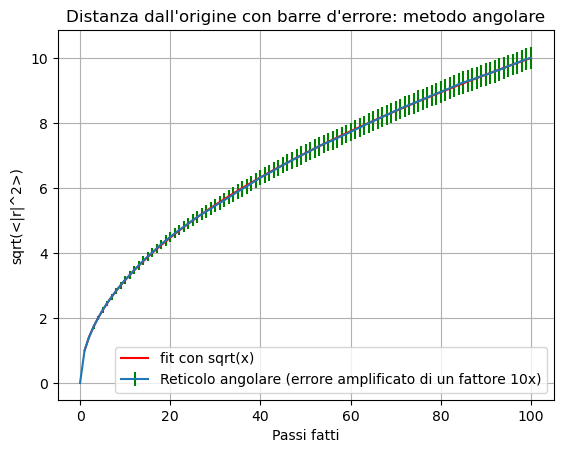

In [3]:
import numpy as np
import matplotlib.pyplot as plt
RW1=np.loadtxt("02.2/Metodo2.dat")

x2=RW1[:,0] #passi
media2=RW1[:,1]
errore2=RW1[:,2]


plt.figure()


plt.errorbar(x2, media2, yerr=errore2*10, ecolor='green', label="Reticolo angolare (errore amplificato di un fattore 10x)")
plt.plot(x,np.sqrt(x), color="red", label="fit con sqrt(x)")



plt.xlabel('Passi fatti')
plt.ylabel('sqrt(<|r|^2>)')
plt.title("Distanza dall'origine con barre d'errore: metodo angolare")
plt.grid(True)
plt.legend()
plt.show()

**COMMENTO AI RISULTATI**

Dall'analisi dei grafici, possiamo notare come l'andamento sia molto simile per entrambe le simulazioni, nonostante i metodi implementati (reticolo cubico e superficie sferica) siano diversi tra loro. In entrambi i casi, infatti, la curva realizzata con i dati simulati segue quasi perfettamente la curva teorica di $k\sqrt{x}$, con $k=1$. Dunque, la sovrapposizione tra i grafici simulati e il fit conferma che la natura diffusiva del processo non viene influenzata da come lo spazio viene campionato (se in modo continuo o discreto).

Inoltre, il fatto che entrambi i grafici seguano l'andamento di $\sqrt{x}$ conferma che la RW segue una legge diffusiva: la RW è infatti un processo di Markov diffusivo in cui l’evoluzione dipende unicamente dallo stato corrente e non dalla storia completa del sistema, ovvero la direzione di ciascun passo viene scelta indipendentemente dai passi precedenti.

Per quanto riguarda le incertezze, esse crescono all'aumentare dei passi ma rimangono comunque piccole. La crescita è associata al fatto che all'aumentare dei passi aumenta anche la dispersione delle traiettorie; assumono valori piccoli grazie al fatto che è stato usato il metodo a blocchi per stimarle, che media campioni indipendenti tra loro.